In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Libraries

In [29]:
data = pd.read_csv('/content/clean_house_prices.csv')

### Load Dataset

In [30]:
print(data.shape)

(1000, 8)


### Check Initial Data Shape

#### Initial Data Size

This `(1000, 8)` output tells us we're starting with 1000 entries (likely houses) and 8 different pieces of information (features) for each.

In [31]:
data = data.drop_duplicates()
print(data.shape)

(944, 8)


### Remove Duplicate Rows and Re-check Shape

After a quick scan for exact duplicate entries, we found and removed some. Our dataset now stands at `(944, 8)`. This means 56 duplicate rows were tidied up, ensuring our analysis isn't skewed by redundant information.

In [32]:
Q1 = data['Area'].quantile(0.25)

Q3 = data['Area'].quantile(0.75)

IQR = Q3 - Q1

lower_bound_area = Q1 - (1.5 * IQR)
upper_bound_area = Q3 + (1.5 * IQR)

### Calculate Outlier Bounds for 'Area' using IQR

In [33]:
Q1 = data['Price'].quantile(0.25)

Q3 = data['Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound_price = Q1 - (1.5 * IQR)
upper_bound_price = Q3 + (1.5 * IQR)

print(Q1, Q3, IQR, lower_bound_area,upper_bound_area,lower_bound_price, upper_bound_price )

1900000000.0 7000000000.0 5100000000.0 -15.625 217.375 -5750000000.0 14650000000.0


### Calculate Outlier Bounds for 'Price' using IQR and Print All Bounds

In [34]:
data1 = data[(data['Area'] < upper_bound_area) & (data['Price'] <  upper_bound_price)].copy()

### Filter Data to Remove Outliers in 'Area' and 'Price'

In [35]:
print(data1.shape)

(846, 8)


### Check Shape After Outlier Removal

#### A Leaner Dataset

After carefully trimming those extreme outliers, our dataset is now a bit leaner, standing at `(846, 8)`. This means we've refined our data to focus on the more typical and representative house listings, which should help our model learn more effectively without being distracted by unusual values.

In [36]:
data1.head()

,Area,Room,parking,warehouse,elevator,Address,Price,Price(USD)
0,63,1,1,1,1,Shahran,1850000000,61666.666667
1,60,1,1,1,1,Shahran,1850000000,61666.666667
2,79,2,1,1,1,Pardis,550000000,18333.333333
3,95,2,1,1,1,Shahrake Qods,902500000,30083.333333
4,123,2,1,1,1,Shahrake Gharb,7000000000,233333.333333


### Display First 5 Rows of Cleaned Data

#### First Look at Cleaned Data

Here's a quick peek at the first five rows of our `data1` DataFrame. Everything looks in order after removing duplicates and outliers. We can see 'Area', 'Room', 'parking', 'warehouse', 'elevator', 'Address', 'Price', and 'Price(USD)' all lined up and ready for more action!

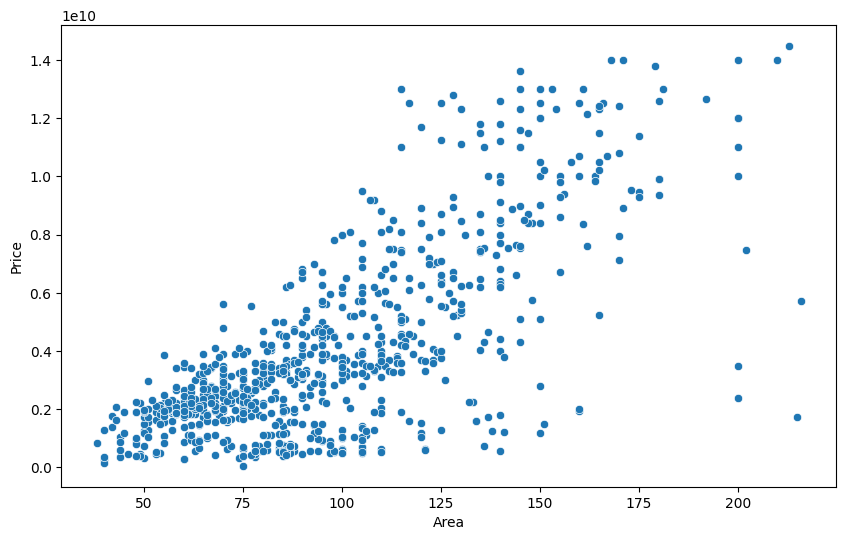

In [37]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=data1, x='Area', y='Price')

plt.show()


### Visualize 'Area' vs. 'Price' Relationship

Price(USD)    1.000000
Price         1.000000
Area          0.737826
Room          0.584695
elevator      0.266708
parking       0.232192
warehouse     0.132261
Name: Price, dtype: float64


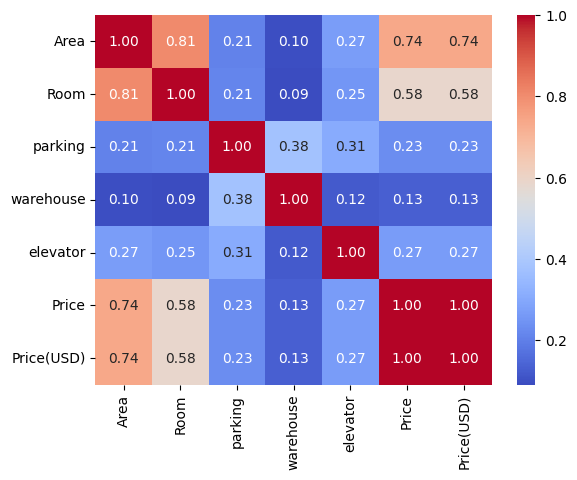

In [38]:
correlations = data1.corr(numeric_only=True)

# 4. Sort the results from highest to lowest correlation
sorted_correlations = correlations['Price'].sort_values(ascending=False)

print(sorted_correlations)

sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")

plt.show()

### Calculate and Visualize Feature Correlations (Heatmap)

Area and Room have multicollinearity which means they can introduce feature reducncay in ML later. so to diagnose this we check if a 2 bedrorom has same size as 3 bedroom

### Diagnose Multicollinearity Between 'Room' and 'Area'

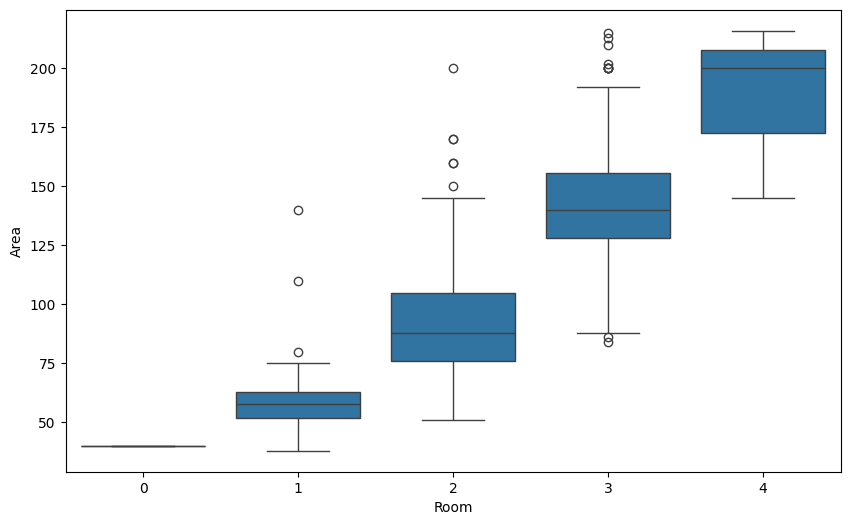

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(data=data1, x ='Room', y = 'Area')
plt.show()

### Box Plot of 'Room' vs. 'Area'

In [40]:
data1['Price_per_sqm'] = data1['Price'] / data1['Area']

data1.head()

,Area,Room,parking,warehouse,elevator,Address,Price,Price(USD),Price_per_sqm
0,63,1,1,1,1,Shahran,1850000000,61666.666667,2.936508e+07
1,60,1,1,1,1,Shahran,1850000000,61666.666667,3.083333e+07
2,79,2,1,1,1,Pardis,550000000,18333.333333,6.962025e+06
3,95,2,1,1,1,Shahrake Qods,902500000,30083.333333,9.500000e+06
4,123,2,1,1,1,Shahrake Gharb,7000000000,233333.333333,5.691057e+07


### Create 'Price_per_sqm' Feature

In [41]:
neighborhood_summary = data1[data1['Address'] != 'Unknown'].groupby('Address')['Price_per_sqm'].agg(['mean', 'count'])

stable_hotspots = neighborhood_summary[neighborhood_summary['count'] >= 8]

print(stable_hotspots.sort_values(by='mean', ascending=False).head(10))


                        mean  count
Address                            
Shahrake Gharb  7.062348e+07     13
Gheitarieh      7.023210e+07     29
Pasdaran        6.957579e+07     23
Farmanieh       6.585204e+07      8
Saadat Abad     6.471896e+07     41
Ekhtiarieh      5.931174e+07     11
Marzdaran       5.779023e+07     10
Heravi          5.422933e+07     17
Abazar          5.326712e+07      8
Punak           4.351996e+07     51


In [42]:
address_counts = data1['Address'].value_counts()

data1 = data1[data1['Address'].map(address_counts) >= 8].copy()

print(data1.shape)


(703, 9)


### Identify Top 10 'Stable Hotspot' Neighborhoods by Price per Sqm

In [43]:
df_model = data1.copy()

x = df_model.drop(['Price', 'Price_per_sqm', 'Price(USD)'], axis=1)

y = df_model['Price']

print(x.columns)

Index(['Area', 'Room', 'parking', 'warehouse', 'elevator', 'Address'], dtype='object')


### Prepare Features (x) and Target (y) for Modeling

#### Our Features for Prediction

This `Index(['Area', 'Room', 'parking', 'warehouse', 'elevator', 'Address'], dtype='object')` printout shows the features we've selected to feed into our model. These are the aspects of a house we believe will help predict its price. Notice 'Address' is still here; we'll need to transform that categorical data into something our model can understand numerically next!

In [44]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
x['Address'] = enc.fit_transform(x['Address'])

print(x.head())

   Area  Room  parking  warehouse  elevator  Address
0    63     1        1          1         1       27
1    60     1        1          1         1       27
2    79     2        1          1         1       17
3    95     2        1          1         1       26
4   123     2        1          1         1       25


### Encode 'Address' Column for Model Compatibility

#### Addresses Transformed!

Just like magic, our 'Address' column, which was text-based, has now been transformed into numerical values! This `x.head()` output beautifully illustrates the change. Each unique address now corresponds to an integer, making it digestible for our machine learning model. Don't worry, the model knows that these numbers don't imply any ordinal relationship, just distinct categories.

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(len(X_train), len(X_test))


562 141


### Split Data into Training and Testing Sets

#### Splitting Our Data

We've successfully split our dataset into training and testing portions! The output `676 170` tells us that 676 house entries will be used to train our XGBoost model, and 170 entries will be held back as unseen data to evaluate how well our model generalizes. This is crucial to ensure our model isn't just memorizing the training data!

In [46]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state = 42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Train XGBoost Regression Model

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 3. Print the results clearly
print(f"Mean Absolute Error: {mae:,.2f}")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"R2 Score: {r2:.4f}")


Mean Absolute Error: 794,958,784.00
Mean Squared Error: 1,740,181,934,996,193,280.00
R2 Score: 0.8153


### Evaluate Model Performance on Test Set

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_train = xgb_model.predict(X_train)

mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

# 3. Print the results clearly
print(f"Mean Absolute Error: {mae:,.2f}")
print(f"Mean Squared Error: {mse:,.2f}")
print(f"R2 Score: {r2:.4f}")


Mean Absolute Error: 151,678,176.00
Mean Squared Error: 83,276,177,464,098,816.00
R2 Score: 0.9913


### Evaluate Model Performance on Training Set

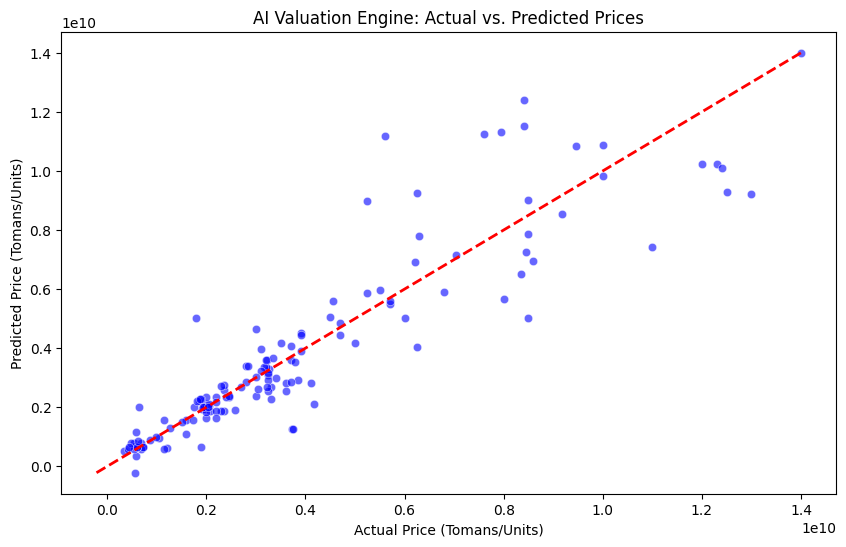

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')

max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# 3. Label your axes clearly
plt.xlabel('Actual Price (Tomans/Units)')
plt.ylabel('Predicted Price (Tomans/Units)')
plt.title('AI Valuation Engine: Actual vs. Predicted Prices')

plt.show()


### Visualize Actual vs. Predicted Prices

In [50]:
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

sorted_importances = importances.sort_values(ascending=False)

print(sorted_importances)


Area         0.472804
Address      0.219115
elevator     0.138008
Room         0.077082
parking      0.076994
warehouse    0.015996
dtype: float32


### Display Feature Importances from XGBoost Model

In [51]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb_model, x, y, cv=5, scoring='r2')
print(scores.mean(), scores.std())

0.821388590335846 0.04046949470690763


#### Interpreting Cross-Validation Results

*   The **mean R2 score of 0.82** tells us that, on average, your model is able to explain about 82% of the variability in house prices. That's a pretty decent score, suggesting your model has a good grasp of the underlying patterns in the data.
*   The **standard deviation of 0.04** indicates how much that R2 score tended to vary across the 5 different folds (splits) of your data. A relatively small standard deviation like this suggests that your model's performance is fairly consistent, regardless of which particular segment of the data it's trained and tested on. In simpler terms, it's not just getting lucky on one specific split, but performing pretty robustly across different scenarios.

### Perform 5-Fold Cross-Validation and Print Results